# Lab04 - Feature Selection: Filter Methods (phần của Thái)
**Kỹ thuật:** Pearson correlation, Mutual Information, f_regression (ANOVA F-test)  
**Mô hình:** SVR, XGBoost, RandomForest  
**Dữ liệu:** House Price Prediction (2000 dòng, 11 feature sau tiền xử lý)

In [1]:
import os
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

SEED = 42
CSV = "House_Price_Prediction_Dataset.csv"   # sua duong dan neu can
OUT = "results_thai"
K_LIST = [3, 5, 7, 9]          # so feature giu lai (them baseline = tat ca)
os.makedirs(OUT, exist_ok=True)

## 1. Tien xu ly (dung chung voi phan cua Nam; neu Nam co preprocess.py

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df = df.drop(columns=["Id"]).drop_duplicates()
    # Condition co thu tu -> ma hoa ordinal; Garage nhi phan; Location one-hot
    df["Condition"] = df["Condition"].map({"Poor": 0, "Fair": 1, "Good": 2, "Excellent": 3})
    df["Garage"] = df["Garage"].map({"No": 0, "Yes": 1})
    df = pd.get_dummies(df, columns=["Location"], dtype=int)
    X, y = df.drop(columns=["Price"]), df["Price"]
    return X, y


X, y = load_data(CSV)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
scaler = StandardScaler().fit(X_train)                      # fit chi tren train
Xtr = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
Xte = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
print(f"Du lieu: {X.shape[0]} dong, {X.shape[1]} feature | train={len(Xtr)}, test={len(Xte)}")

Du lieu: 2000 dong, 11 feature | train=1600, test=400


## 2. Filter methods: tinh diem tren TAP TRAIN (tranh data leakage)

In [3]:
scores = pd.DataFrame(index=X.columns)
scores["Pearson"] = [abs(np.corrcoef(Xtr[c], y_train)[0, 1]) for c in X.columns]
scores["MutualInfo"] = mutual_info_regression(Xtr, y_train, random_state=SEED)
scores["F_regression"] = f_regression(Xtr, y_train)[0]
scores.to_csv(f"{OUT}/filter_scores.csv", float_format="%.5f")
print("\nDiem cua cac Filter method:\n", scores.round(4).sort_values("Pearson", ascending=False))

rankings = {m: scores[m].sort_values(ascending=False).index.tolist() for m in scores.columns}


Diem cua cac Filter method:
                    Pearson  MutualInfo  F_regression
Floors              0.0681      0.0000        7.4411
Bathrooms           0.0393      0.0000        2.4667
Location_Urban      0.0256      0.0000        1.0480
Location_Suburban   0.0228      0.0000        0.8277
Condition           0.0212      0.0087        0.7164
YearBuilt           0.0144      0.0000        0.3331
Location_Rural      0.0049      0.0142        0.0378
Garage              0.0038      0.0038        0.0234
Location_Downtown   0.0014      0.0000        0.0033
Area                0.0009      0.0000        0.0012
Bedrooms            0.0000      0.0000        0.0000


## 3. Mo hinh

In [4]:
def make_models():
    svr = TransformedTargetRegressor(          # SVR can y duoc chuan hoa
        regressor=SVR(kernel="rbf", C=10, epsilon=0.1), transformer=StandardScaler())
    return {
        "SVR": svr,
        "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                random_state=SEED, n_jobs=-1),
        "RandomForest": RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1),
    }


def evaluate(model, cols):
    t0 = time.time()
    model.fit(Xtr[cols], y_train)
    t_fit = time.time() - t0
    pred = model.predict(Xte[cols])
    return {"R2": r2_score(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "MAE": mean_absolute_error(y_test, pred),
            "Fit_time_s": t_fit}

## 4. Chay thuc nghiem

In [5]:
rows = []
for name in make_models():                                   # baseline: tat ca feature
    r = evaluate(make_models()[name], list(X.columns))
    rows.append({"Method": "Baseline (all)", "K": X.shape[1], "Model": name,
                 "Features": ", ".join(X.columns), **r})

for method, ranked in rankings.items():
    for k in K_LIST:
        cols = ranked[:k]
        for name in make_models():
            r = evaluate(make_models()[name], cols)
            rows.append({"Method": method, "K": k, "Model": name,
                         "Features": ", ".join(cols), **r})
        print(f"{method:13s} K={k}: {cols}")

res = pd.DataFrame(rows)
res.to_csv(f"{OUT}/filter_results.csv", index=False, float_format="%.4f")

pivot = res.pivot_table(index=["Method", "K"], columns="Model", values="R2")
print("\nR2 tren tap test:\n", pivot.round(4))

Pearson       K=3: ['Floors', 'Bathrooms', 'Location_Urban']


Pearson       K=5: ['Floors', 'Bathrooms', 'Location_Urban', 'Location_Suburban', 'Condition']


Pearson       K=7: ['Floors', 'Bathrooms', 'Location_Urban', 'Location_Suburban', 'Condition', 'YearBuilt', 'Location_Rural']


Pearson       K=9: ['Floors', 'Bathrooms', 'Location_Urban', 'Location_Suburban', 'Condition', 'YearBuilt', 'Location_Rural', 'Garage', 'Location_Downtown']


MutualInfo    K=3: ['Location_Rural', 'Condition', 'Garage']


...

MutualInfo    K=9: ['Location_Rural', 'Condition', 'Garage', 'Bathrooms', 'Bedrooms', 'Area', 'YearBuilt', 'Floors', 'Location_Downtown']


F_regression  K=3: ['Floors', 'Bathrooms', 'Location_Urban']


F_regression  K=5: ['Floors', 'Bathrooms', 'Location_Urban', 'Location_Suburban', 'Condition']


F_regression  K=7: ['Floors', 'Bathrooms', 'Location_Urban', 'Location_Suburban', 'Condition', 'YearBuilt', 'Location_Rural']


F_regression  K=9: ['Floors', 'Bathrooms', 'Location_Urban', 'Location_Suburban', 'Condition', 'YearBuilt', 'Location_Rural', 'Garage', 'Location_Downtown']

R2 tren tap test:
 Model              RandomForest     SVR  XGBoost
Method         K                                
Baseline (all) 11       -0.1061 -0.4306  -0.0736
F_regression   3        -0.0033 -0.0252  -0.0026
               5        -0.1379 -0.1614  -0.0773
               7        -0.1732 -0.2270  -0.0962
               9        -0.1530 -0.2120  -0.0965
MutualInfo     3        -0.0132 -0.0267  -0.0136
               5        -0.1950 -0.1561  -0.0738
               7        -0.1227 -0.4201  -0.1025
               9        -0.0988 -0.4785  -0.0891
Pearson        3        -0.0033 -0.0252  -0.0026
               5        -0.1379 -0.1614  -0.0773
               7        -0.1732 -0.2270  -0.0962
               9        -0.1530 -0.2120  -0.0965


## 5. Bieu do

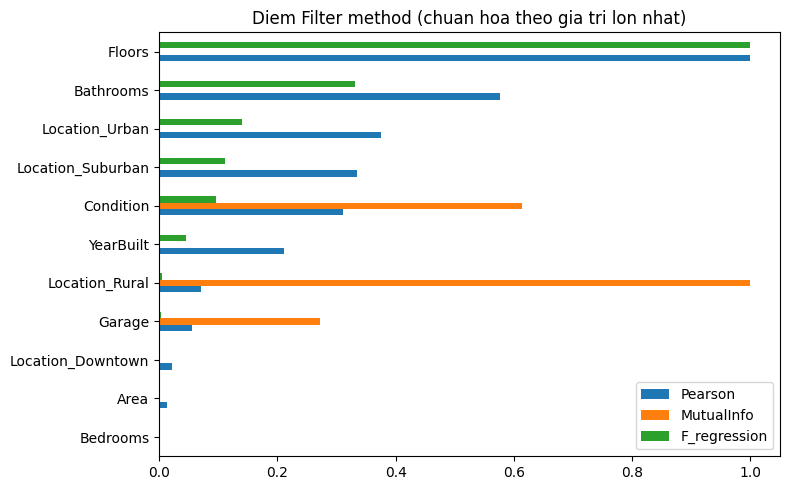

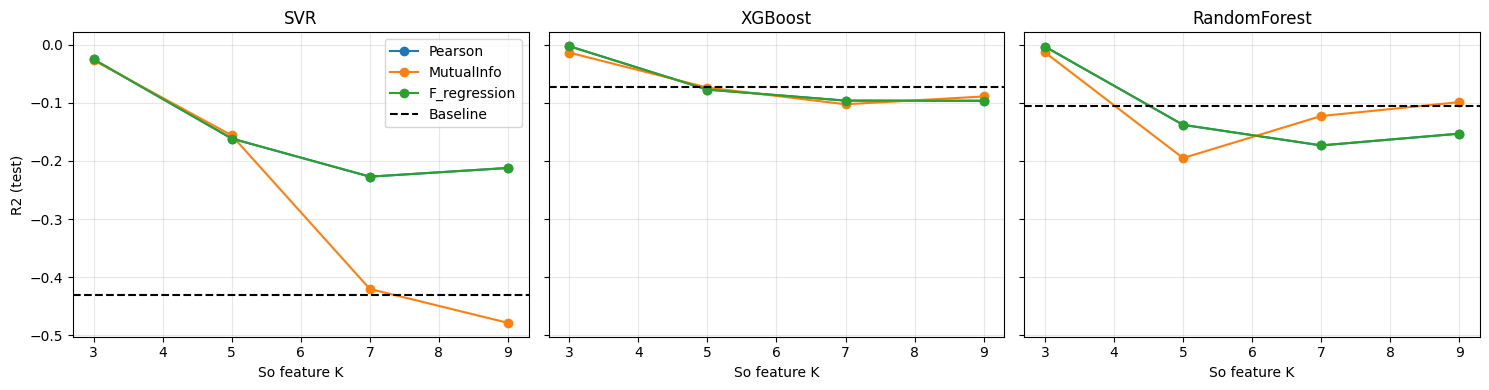


Da luu ket qua vao thu muc 'results_thai/'


In [6]:
# 5a. Diem cua tung feature (chuan hoa ve [0,1] de so sanh)
norm = scores / scores.max()
ax = norm.sort_values("Pearson").plot.barh(figsize=(8, 5))
ax.set_title("Diem Filter method (chuan hoa theo gia tri lon nhat)")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_filter_scores.png", dpi=150); plt.show()

# 5b. R2 theo K cho tung mo hinh
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, model in zip(axes, ["SVR", "XGBoost", "RandomForest"]):
    for method in scores.columns:
        d = res[(res.Method == method) & (res.Model == model)].sort_values("K")
        ax.plot(d.K, d.R2, marker="o", label=method)
    base = res[(res.Method == "Baseline (all)") & (res.Model == model)].R2.iloc[0]
    ax.axhline(base, color="k", ls="--", label="Baseline")
    ax.set_title(model); ax.set_xlabel("So feature K"); ax.grid(alpha=.3)
axes[0].set_ylabel("R2 (test)"); axes[0].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/fig_r2_vs_k.png", dpi=150); plt.show()

print(f"\nDa luu ket qua vao thu muc '{OUT}/'")